# Профили тканей по всей поверхности лёгких

Этот notebook показывает batch-результат без привязки к электродам: лучи строились от равномерно выбранных точек всей сегментированной поверхности лёгких к наружной границе тела.

Важно: поверхности вдоха и выдоха сэмплированы независимо. Пока registration gate не пройден, различие их распределений **не является** парным дыхательным изменением.

**Техническое воспроизведение, 14.09.2026.** Ноутбук сохраняет историческую постановку и ограничения. Повторное исполнение проверяет расчёты и отображение; оно не меняет научный статус ветки. Тяжёлые результаты читаются из сохранённых пакетов с исходными проверками целостности. Источники и конфигурации используются из этой папки проекта.

In [1]:
# Portable execution support; scientific sources remain in this checkout.
import os
import sys
from pathlib import Path
_start = Path(os.environ.get("BREATH_NOTEBOOK_DIR", Path.cwd())).resolve()
_support = next((folder for parent in (_start, *_start.parents)
                 for folder in (parent, parent / "notebooks", parent / "breath geometry/notebooks")
                 if (folder / "execution_support.py").is_file()), None)
if _support is None:
    raise FileNotFoundError("Не найден notebooks/execution_support.py")
sys.path.insert(0, str(_support))
from execution_support import roots, copdgene_case_dir, lungct_input
REPO_ROOT, ARTIFACT_ROOT = roots()
repo_root = REPO_ROOT


In [2]:
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display


summary_path = (
    ARTIFACT_ROOT / "results/profiles/dirlab_copdgene__copd1__summary.json"
)
profile_paths = {
    "Выдох (fixed)": (
        ARTIFACT_ROOT
        / "results/profiles/dirlab_copdgene__copd1__fixed-expiration_normal.csv"
    ),
    "Вдох (moving)": (
        ARTIFACT_ROOT
        / "results/profiles/dirlab_copdgene__copd1__moving-inspiration_max.csv"
    ),
}
missing = [
    path.name
    for path in [summary_path, *profile_paths.values()]
    if not path.is_file()
]
if missing:
    raise FileNotFoundError(
        "Нет batch-артефактов профилей: " + ", ".join(missing)
    )

summary = json.loads(summary_path.read_text(encoding="utf-8"))
frames = {}
for phase, path in profile_paths.items():
    frame = pd.read_csv(path)
    frame["valid"] = frame["valid"].astype(bool)
    frame["phase"] = phase
    frames[phase] = frame
profiles = pd.concat(frames.values(), ignore_index=True)

print(
    f"Субъект: {summary['dataset_id']}/{summary['subject_id']}; "
    f"покрытие: {summary['coverage']}."
)
print(
    "Профили загружены из batch CSV; DICOM/NIfTI и приватные пути "
    "в notebook не загружаются."
)

Субъект: dirlab_copdgene/copd1; покрытие: whole-segmented-lung-surface_no-electrode-filter.
Профили загружены из batch CSV; DICOM/NIfTI и приватные пути в notebook не загружаются.


## Покрытие и сводка QC

Толщина — полный путь от поверхности лёгкого до наружной границы тела. Компоненты по HU — диагностическое разложение этого пути, а не полноценная анатомическая сегментация.

In [3]:
phase_map = {
    "Выдох (fixed)": summary["fixed"],
    "Вдох (moving)": summary["moving"],
}
summary_rows = []
for phase, values in phase_map.items():
    summary_rows.append(
        {
            "Фаза": phase,
            "Кандидатов": values["candidate_count"],
            "Валидных": values["valid_count"],
            "Валидных, %": (
                100 * values["valid_count"] / values["candidate_count"]
            ),
            "Толщина p10, мм": values["thickness_p10_mm"],
            "Толщина медиана, мм": values["thickness_median_mm"],
            "Толщина p90, мм": values["thickness_p90_mm"],
            "Жир медиана, мм": values["fat_median_mm"],
            "Мышцы медиана, мм": values["muscle_median_mm"],
            "Кость медиана, мм": values["bone_median_mm"],
        }
    )
phase_summary = pd.DataFrame(summary_rows)
display(phase_summary.round(2))
display(Markdown(
    f"**Статус парного анализа:** `{summary['paired_status']}`.  "
    f"{summary['warning']}"
))

,Фаза,Кандидатов,Валидных,"Валидных, %","Толщина p10, мм","Толщина медиана, мм","Толщина p90, мм","Жир медиана, мм","Мышцы медиана, мм","Кость медиана, мм"
0,Выдох (fixed),6529,3305,50.62,22.43,35.80,61.18,10.44,18.36,2.93
1,Вдох (moving),8013,4238,52.89,16.87,32.21,65.88,9.66,15.62,2.21


**Статус парного анализа:** `blocked_registration_gate`.  Fixed and moving summaries use independently sampled surfaces; their difference is not a paired respiratory effect.

Фаза,Вдох (moving),Выдох (fixed)
Причина,,
crosses_lung_interior,2976,2639
fov_truncated,267,167
lung_reentry,532,418
valid,4238,3305


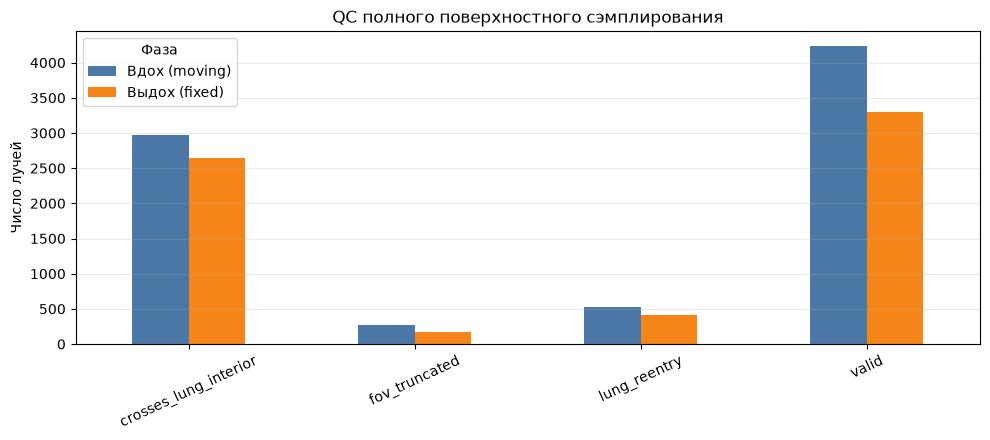

In [4]:
qc_rows = []
for phase, values in phase_map.items():
    valid = values["valid_count"]
    qc_rows.append({"Фаза": phase, "Причина": "valid", "Число": valid})
    for reason, count in values["invalid_reasons"].items():
        qc_rows.append({"Фаза": phase, "Причина": reason, "Число": count})
qc_table = pd.DataFrame(qc_rows)
display(
    qc_table.pivot(
        index="Причина", columns="Фаза", values="Число"
    ).fillna(0).astype(int)
)

qc_plot = qc_table.pivot(
    index="Причина", columns="Фаза", values="Число"
).fillna(0)
ax = qc_plot.plot.bar(figsize=(10, 4.5), color=["#4c78a8", "#f58518"])
ax.set_ylabel("Число лучей")
ax.set_xlabel("")
ax.set_title("QC полного поверхностного сэмплирования")
ax.tick_params(axis="x", rotation=25)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Независимые распределения фаз

Графики полезны для QC диапазонов и выбросов. Они не дают `Δ` ткани в одной и той же анатомической точке.

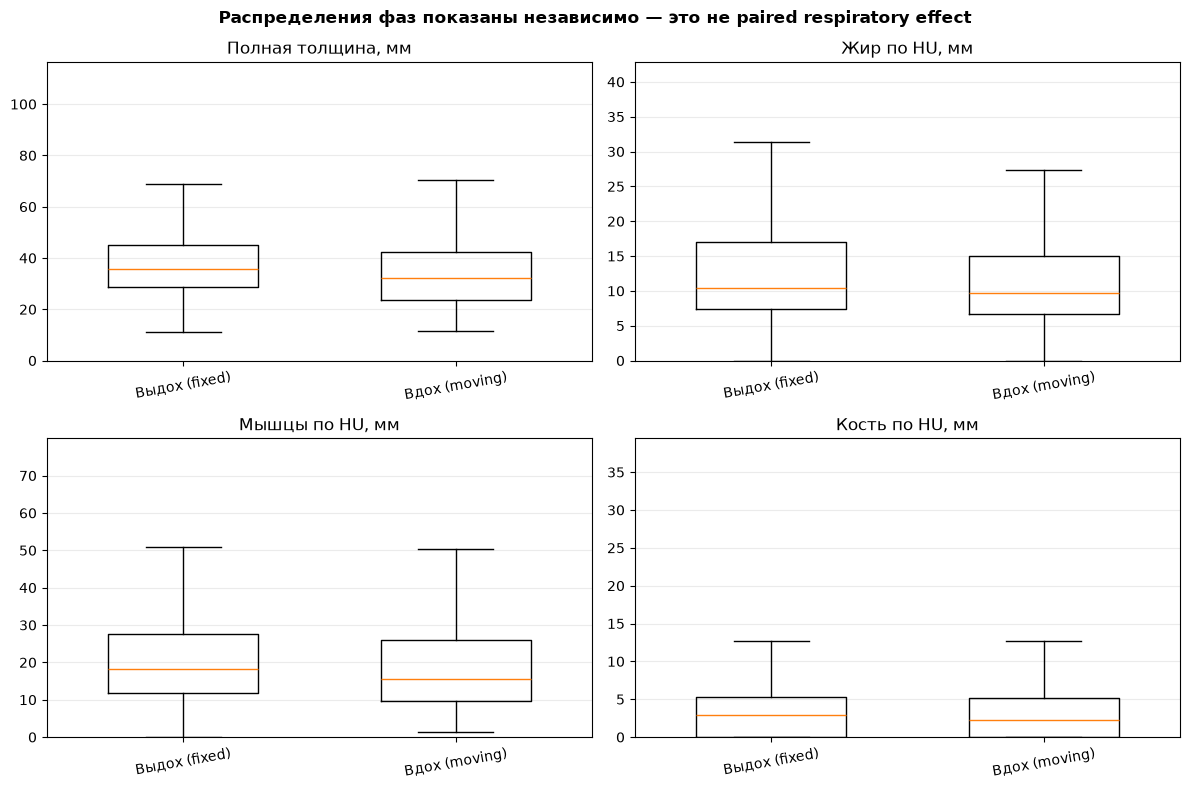

In [5]:
valid_frames = {
    phase: frame.loc[frame["valid"]].copy()
    for phase, frame in frames.items()
}
metrics = [
    ("thickness_mm", "Полная толщина, мм"),
    ("fat_mm", "Жир по HU, мм"),
    ("muscle_mm", "Мышцы по HU, мм"),
    ("bone_mm", "Кость по HU, мм"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (column, title) in zip(axes.ravel(), metrics, strict=True):
    values = [
        valid_frames[phase][column].dropna().to_numpy()
        for phase in profile_paths
    ]
    ax.boxplot(
        values,
        tick_labels=list(profile_paths),
        showfliers=False,
        widths=0.55,
    )
    combined = np.concatenate(values)
    upper = np.quantile(combined, 0.99)
    ax.set_ylim(0, max(upper * 1.08, 1.0))
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=10)
fig.suptitle(
    "Распределения фаз показаны независимо — это не paired respiratory effect",
    fontweight="bold",
)
plt.tight_layout()
plt.show()

## Региональная проверка

Регионы определены геометрически для QC покрытия всей поверхности. Они не являются областями электродов.

In [6]:
region_rows = []
for phase, frame in valid_frames.items():
    for region, group in frame.groupby("region"):
        region_rows.append(
            {
                "Фаза": phase,
                "Регион": region,
                "n": len(group),
                "Толщина, медиана мм": group["thickness_mm"].median(),
                "Жир, медиана мм": group["fat_mm"].median(),
                "Мышцы, медиана мм": group["muscle_mm"].median(),
                "Кость, медиана мм": group["bone_mm"].median(),
            }
        )
region_table = pd.DataFrame(region_rows).sort_values(["Регион", "Фаза"])
display(region_table.round(2))

,Фаза,Регион,n,"Толщина, медиана мм","Жир, медиана мм","Мышцы, медиана мм","Кость, медиана мм"
6,Вдох (moving),anterior,1179,32.87,15.52,14.62,0.00
0,Выдох (fixed),anterior,955,37.03,17.11,15.54,0.74
7,Вдох (moving),inferior,15,25.27,16.35,6.61,2.21
1,Выдох (fixed),inferior,178,55.26,14.04,29.11,0.00
8,Вдох (moving),left,783,25.08,8.90,10.89,0.75
2,Выдох (fixed),left,455,31.09,10.40,12.74,2.23
9,Вдох (moving),posterior,1458,38.77,8.21,25.48,5.21
3,Выдох (fixed),posterior,1202,36.24,8.07,24.32,5.11
10,Вдох (moving),right,803,21.63,8.05,9.64,1.48
4,Выдох (fixed),right,505,32.55,9.68,13.32,2.98


## Пространственное распределение

Цветом показана полная skin-to-lung толщина для валидных профилей. Для компактности визуализации отображается детерминированная подвыборка, а таблицы выше рассчитаны по всем профилям.

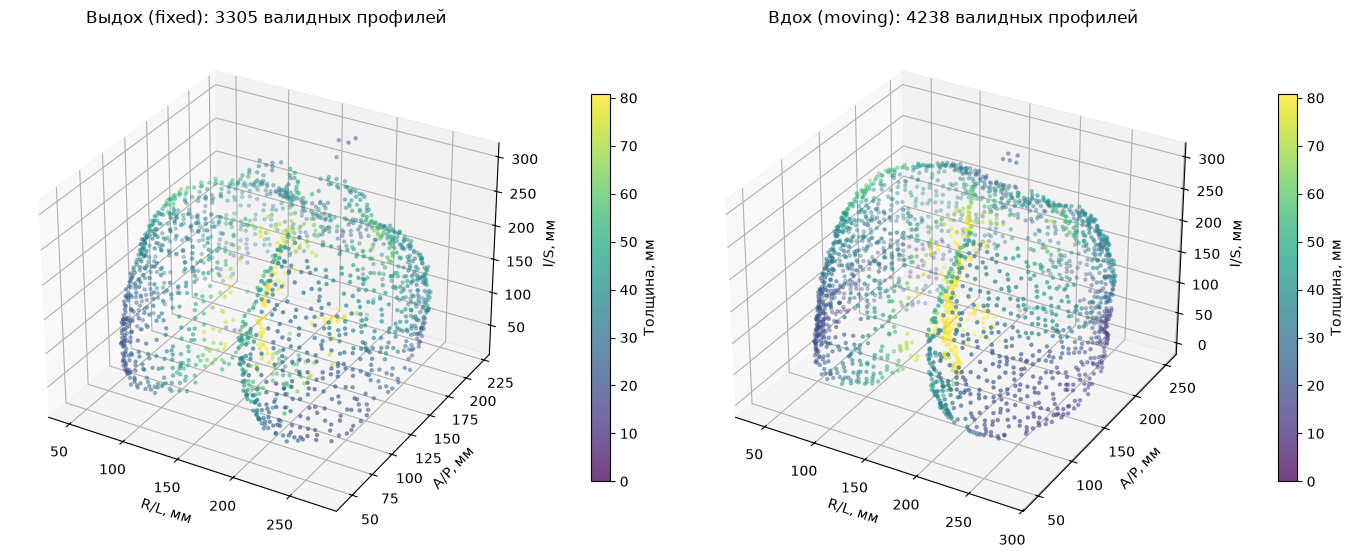

In [7]:
fig = plt.figure(figsize=(14, 6))
for index, (phase, frame) in enumerate(valid_frames.items(), start=1):
    ax = fig.add_subplot(1, 2, index, projection="3d")
    step = max(1, len(frame) // 1600)
    sample = frame.iloc[::step]
    scatter = ax.scatter(
        sample["lung_x_mm"],
        sample["lung_y_mm"],
        sample["lung_z_mm"],
        c=sample["thickness_mm"],
        cmap="viridis",
        s=5,
        alpha=0.75,
        vmin=0,
        vmax=profiles.loc[profiles["valid"], "thickness_mm"].quantile(0.95),
    )
    ax.set_title(f"{phase}: {len(frame)} валидных профилей")
    ax.set_xlabel("R/L, мм")
    ax.set_ylabel("A/P, мм")
    ax.set_zlabel("I/S, мм")
    fig.colorbar(scatter, ax=ax, shrink=0.68, pad=0.10, label="Толщина, мм")
plt.tight_layout()
plt.show()

## Инварианты разложения толщины

Проверяется согласованность сохранённых чисел. Малый остаток подтверждает арифметику, но не валидирует HU-классификацию мышцы и жира.

In [8]:
invariant_rows = []
for phase, frame in valid_frames.items():
    total_components = (
        frame["fat_mm"]
        + frame["muscle_mm"]
        + frame["bone_mm"]
        + frame["other_mm"]
    )
    soft_components = (
        frame["fat_mm"] + frame["muscle_mm"] + frame["other_mm"]
    )
    invariant_rows.append(
        {
            "Фаза": phase,
            "max |thickness − сумма компонентов|, мм": (
                frame["thickness_mm"] - total_components
            ).abs().max(),
            "max |soft_tissue − fat − muscle − other|, мм": (
                frame["soft_tissue_mm"] - soft_components
            ).abs().max(),
        }
    )
invariant_table = pd.DataFrame(invariant_rows)
display(invariant_table)

,Фаза,"max |thickness − сумма компонентов|, мм","max |soft_tissue − fat − muscle − other|, мм"
0,Выдох (fixed),2.842171e-14,2.131628e-14
1,Вдох (moving),4.263256e-14,2.842171e-14


In [9]:
def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

artifact_table = pd.DataFrame(
    [
        {
            "Артефакт": path.relative_to(ARTIFACT_ROOT).as_posix(),
            "SHA-256": sha256_file(path),
        }
        for path in [summary_path, *profile_paths.values()]
    ]
)
display(artifact_table)

,Артефакт,SHA-256
0,results/profiles/dirlab_copdgene__copd1__summa...,d669cb177c7ab955e50c619942990239288b4935e531ea...
1,results/profiles/dirlab_copdgene__copd1__fixed...,069c9f884d429ccf59207c43df0a4bcb5183fec1dd702b...
2,results/profiles/dirlab_copdgene__copd1__movin...,78728433d8625b434ddabf287a4d69b5a6b1e5a1b81001...


In [10]:
if summary["paired_status"] == "available_gate_passed":
    verdict = (
        "## Итог: парные профили доступны\n\n"
        "Можно переходить к subject-level анализу локальных изменений."
    )
else:
    verdict = (
        "## Итог: сейчас доступны только QC и независимые описания фаз\n\n"
        "**Вычитать медианы вдоха и выдоха нельзя:** точки поверхности не "
        "сопоставлены, а registration gate не пройден. Следующий научно "
        "корректный шаг — улучшить регистрацию, повторить benchmark и только "
        "затем строить парные карты изменения толщины."
    )
display(Markdown(verdict))

## Итог: сейчас доступны только QC и независимые описания фаз

**Вычитать медианы вдоха и выдоха нельзя:** точки поверхности не сопоставлены, а registration gate не пройден. Следующий научно корректный шаг — улучшить регистрацию, повторить benchmark и только затем строить парные карты изменения толщины.